# FineSightBench — Dataset Introduction

**FineSightBench** is a fine-grained visual benchmark for evaluating Vision-Language Models (VLMs) on their ability to perceive and reason about *very small* visual targets. It is designed to stress-test how VLMs degrade as object size shrinks toward the pixel level.

## Two complementary subsets

| Subset | Task family | # Samples | Description |
|---|---|---|---|
| **FineSight-Perception** | Single-object recognition | 4,200 | Identify a single tiny target on a 448×448 canvas |
| **FineSight-Reasoning**  | Multi-object chain reasoning | 3,920 | Count / compare / locate / read multiple tiny targets |

## Difficulty axes

- **Pixel size** of each target ∈ `{4, 8, 12, 16, 24, 32, 48}` px (canvas is 448×448)
- **Object count** (reasoning only) ∈ `{2, 4, 8, 10, 15, 20}` per image

## Task types

**Perception (6):** `letter_recognition`, `animal_recognition`, `block_recognition`, `color_block_recognition`, `shape_recognition`, `text_recognition` (scene-text / TextWild).

**Reasoning (6):** `spatial_chain`, `comparison_chain`, `counting_chain`, `blur_chain`, `text_reading_chain`, `text_counting_chain`.

Below we sample one representative image **per task type** — all 6 perception tasks (top row) and all 6 reasoning tasks (bottom row) — and overlay a **red circle** on every target so the tiny objects can be located even when they are hard to see at a glance.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from PIL import Image

ROOT = Path('..').resolve()
PERCEPTION_DIR = ROOT / 'data' / 'full_perception'
REASONING_DIR  = ROOT / 'data' / 'full_reasoning'

with open(PERCEPTION_DIR / 'labels.json') as f:
    perception = json.load(f)
with open(REASONING_DIR / 'labels.json') as f:
    reasoning = json.load(f)

print('Perception samples :', perception['dataset_info']['num_samples'])
print('Reasoning samples  :', reasoning['dataset_info']['num_samples'])

Perception samples : 4200
Reasoning samples  : 3920


In [2]:
# Helper: pick the first sample whose image_id matches all required substrings
def pick(samples, must_contain):
    for s in samples:
        if all(tok in s['image_id'] for tok in must_contain):
            return s
    raise ValueError(f'No sample matching {must_contain}')

# Helper: pick one sample with exact image_id
def pick_exact(samples, image_id):
    for s in samples:
        if s.get('image_id') == image_id:
            return s
    raise ValueError(f'No sample matching exact image_id={image_id}')

# Use 32 px targets so they are visible in the figure (the dataset goes down to 4 px)
PX = '32px'

# Prefer relatively larger object counts for reasoning tasks.
# For textwild reasoning tasks, available counts are n2/n4/n6/n8.
def pick_reasoning(samples, prefix, preferred_counts):
    for n in preferred_counts:
        token = f'n{n}'
        for s in samples:
            iid = s['image_id']
            if prefix in iid and PX in iid and token in iid:
                return s
    raise ValueError(f'No reasoning sample for {prefix} at counts {preferred_counts}')

picks = [
    # ---- Perception (row 1): all 6 task types ----
    ('Perception · Letter',          PERCEPTION_DIR, pick(perception['samples'], ['perception_letter_',                    PX]), True),
    ('Perception · Animal',          PERCEPTION_DIR, pick(perception['samples'], ['perception_animal_',                    PX]), True),
    ('Perception · Block',           PERCEPTION_DIR, pick(perception['samples'], ['perception_block_',                     PX]), True),
    ('Perception · Color block',     PERCEPTION_DIR, pick(perception['samples'], ['perception_color_block_',               PX]), True),
    ('Perception · Shape',           PERCEPTION_DIR, pick(perception['samples'], ['perception_shape_',                     PX]), True),
    ('Perception · Scene text',      PERCEPTION_DIR, pick(perception['samples'], ['textwild_perception_text_recognition_', PX]), False),

    # ---- Reasoning (row 2): all 6 task types, with relatively more objects ----
    ('Reasoning · Spatial chain',    REASONING_DIR, pick_reasoning(reasoning['samples'], 'reasoning_spatial_chain_',  [10, 8, 4]), True),
    ('Reasoning · Comparison chain', REASONING_DIR, pick_reasoning(reasoning['samples'], 'reasoning_comparison_chain_', [10, 8, 4]), True),
    ('Reasoning · Counting chain',   REASONING_DIR, pick_reasoning(reasoning['samples'], 'reasoning_counting_chain_',   [20, 15, 10]), True),
    ('Reasoning · Blur chain',       REASONING_DIR, pick_exact(reasoning['samples'], 'reasoning_blur_chain_32px_n10_02425'), True),
    ('Reasoning · Text reading',     REASONING_DIR, pick_reasoning(reasoning['samples'], 'textwild_reasoning_text_reading_chain_',  [8, 6, 4]), False),
    ('Reasoning · Text counting',    REASONING_DIR, pick_reasoning(reasoning['samples'], 'textwild_reasoning_text_counting_chain_', [8, 6, 4]), False),
]

for title, _, s, draw_circles in picks:
    n = len(s['metadata'].get('targets', []))
    print(f'{title:35s}  ->  {s["image_id"]}  (#targets={n}, circles={draw_circles})')

Perception · Letter                  ->  perception_letter_32px_00500  (#targets=1, circles=True)
Perception · Animal                  ->  perception_animal_32px_01200  (#targets=1, circles=True)
Perception · Block                   ->  perception_block_32px_01900  (#targets=1, circles=True)
Perception · Color block             ->  perception_color_block_32px_02600  (#targets=1, circles=True)
Perception · Shape                   ->  perception_shape_32px_03300  (#targets=1, circles=True)
Perception · Scene text              ->  textwild_perception_text_recognition_32px_00500  (#targets=1, circles=False)
Reasoning · Spatial chain            ->  reasoning_spatial_chain_32px_n10_00460  (#targets=10, circles=True)
Reasoning · Comparison chain         ->  reasoning_comparison_chain_32px_n10_01020  (#targets=10, circles=True)
Reasoning · Counting chain           ->  reasoning_counting_chain_32px_n20_01820  (#targets=20, circles=True)
Reasoning · Blur chain               ->  reasoning_blur_ch

Saved -> /home/snt/projects_lujun/FineSightBench/outputs/dataset_intro_overview.png


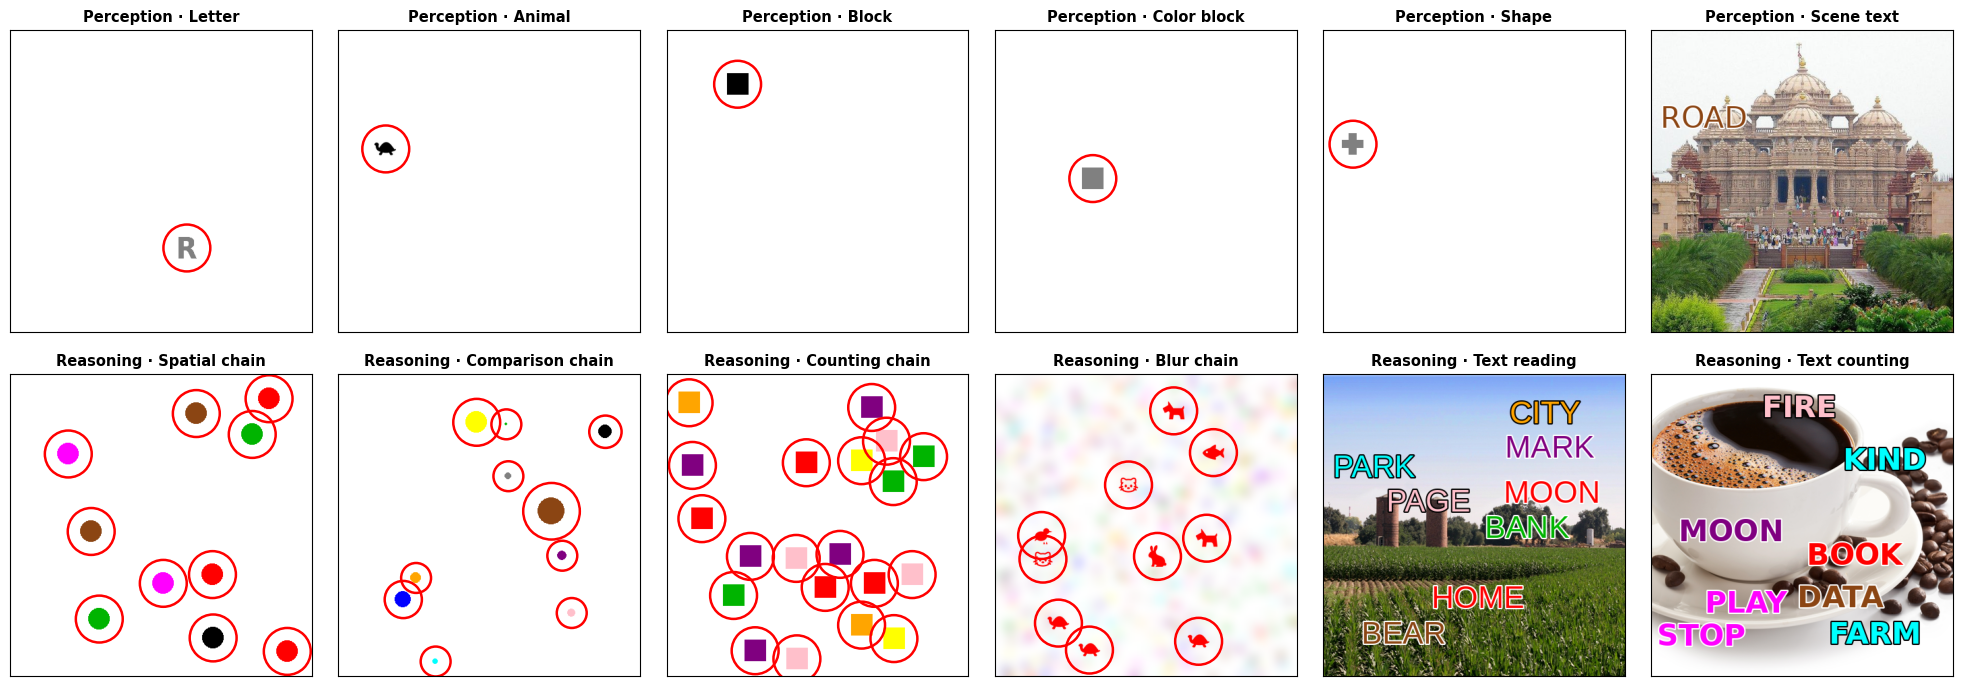

In [3]:
# ----- plot a compact 2x6 grid (row 1 = perception, row 2 = reasoning) -----
fig, axes = plt.subplots(2, 6, figsize=(20.0, 7.6))
fig.patch.set_alpha(0)

for ax, (title, base, s, draw_circles) in zip(axes.flat, picks):
    ax.set_facecolor('none')
    img = Image.open(base / s['image_path']).convert('RGB')
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10.5, fontweight='bold', pad=6)

    # Overlay a red circle around every target unless disabled for this task.
    if draw_circles:
        for t in s['metadata'].get('targets', []):
            x, y = t['position']
            sz = t.get('size', 32)
            cx, cy = x + sz / 2, y + sz / 2
            r = max(sz, 18) * 0.9 + 6
            ax.add_patch(Circle((cx, cy), r, fill=False, edgecolor='red', linewidth=1.8))

# fig.suptitle(
#     f'FineSightBench — sample tasks (target pixel size = {PX})',
#     fontsize=14, fontweight='bold', y=0.97,
# )
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.03, top=0.88, wspace=0.03, hspace=0.14)
out = ROOT / 'outputs' / 'dataset_intro_overview.png'
out.parent.mkdir(exist_ok=True, parents=True)
fig.savefig(out, dpi=200, bbox_inches='tight', transparent=True)
print('Saved ->', out)
plt.show()

Each red circle marks the location of a target object that the VLM must perceive in order to answer. As the **pixel size** parameter is reduced from 48 → 4, these targets become only a few pixels wide, providing a controlled probe of fine-grained visual acuity.